### Data Cleaning For Churn Prediction Project

#### 1. Setup

In [1]:
#Import necessary libraries.
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns


#### 2. Load The Data

In [3]:
#Load the dataset.
df = pd.read_csv("../data/raw_data.csv")

#### 3. Understand The Data

In [ ]:
#Check the structure of the dataset.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#Columns of the dataset
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
#Check the dimensions of the dataset.
df.shape

(7043, 21)

In [ ]:
#Check the summary statistics of the dataset.
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

* There is no missing data. 
* TotalCharges is classified as object, instead it should be float.

In [ ]:
#Convert TotalCharges to numeric.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].describe())

float64
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


#### 4. Data Cleaning

In [ ]:
#Check for duplicates in the dataset.
df.duplicated().sum()

np.int64(0)

In [ ]:
#Function to check misspelled values in categorical columns.
def check_unique_values(df, columns):
    for col in columns:
        unique_vals = df[col].unique()
        print(f"Column: {col}")
        print(f"Number of unique values: {len(unique_vals)}")
        print(f"Unique values: {unique_vals}\n")
        

In [ ]:
#Identify categorical columns to a list.
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

#Check the result.
print(categorical_cols)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [ ]:
#Check unique values in categorical columns.
check_unique_values(df, categorical_cols)

Column: customerID
Number of unique values: 7043
Unique values: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

Column: gender
Number of unique values: 2
Unique values: ['Female' 'Male']

Column: Partner
Number of unique values: 2
Unique values: ['Yes' 'No']

Column: Dependents
Number of unique values: 2
Unique values: ['No' 'Yes']

Column: PhoneService
Number of unique values: 2
Unique values: ['No' 'Yes']

Column: MultipleLines
Number of unique values: 3
Unique values: ['No phone service' 'No' 'Yes']

Column: InternetService
Number of unique values: 3
Unique values: ['DSL' 'Fiber optic' 'No']

Column: OnlineSecurity
Number of unique values: 3
Unique values: ['No' 'Yes' 'No internet service']

Column: OnlineBackup
Number of unique values: 3
Unique values: ['Yes' 'No' 'No internet service']

Column: DeviceProtection
Number of unique values: 3
Unique values: ['No' 'Yes' 'No internet service']

Column: TechSupport
Number of unique values: 3
Unique va

* There are no duplicates in the dataset
* We don't need the customerID column for our analysis, so we dropped it.
* We saw that "No", "No internet service" and "No phone service" are the same things. We simply changed them into "No".

In [ ]:
#No internet service and No phone service values are not necessary. We can replace them with No.
to_be_cleaned = ['No internet service', 'No phone service']

df.replace(to_replace=to_be_cleaned, value='No', inplace=True)

In [ ]:
#Check the unique values of OnlineSecurity and MultipleLines columns after replacement.
print("OnlineSecurity unique değerleri:", df['OnlineSecurity'].unique())
print("MultipleLines unique değerleri:", df['MultipleLines'].unique())

OnlineSecurity unique değerleri: ['No' 'Yes']
MultipleLines unique değerleri: ['No' 'Yes']


In [ ]:
#Check for duplicates in the dataset.
df.duplicated().sum()

np.int64(0)

In [ ]:
#We don't need the customerID column for our analysis, so we can drop it.
df = df.drop(['customerID'], axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### 5. Outlier Check

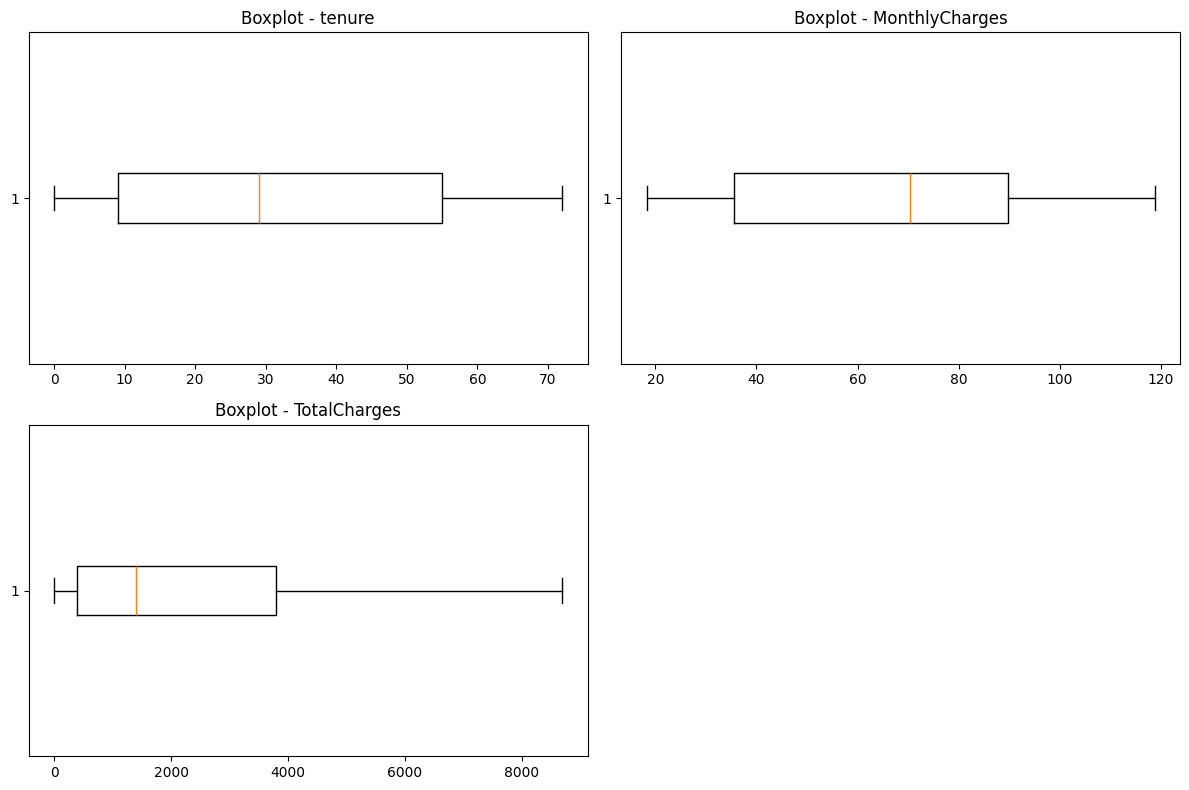

In [ ]:
#Identify numeric columns to a list.
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

#Visualize the distribution of numeric columns using boxplots.
n_cols = 2  
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()

In [ ]:
#Identify outliers using the IQR method and summarize the findings.
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_summary.append({
        "column": col,
        "outlier_count": len(outliers),
        "lower_bound": round(lower,2),
        "upper_bound": round(upper,2)
    })

pd.DataFrame(outlier_summary)

,column,outlier_count,lower_bound,upper_bound
0,tenure,0,-60.00,124.00
1,MonthlyCharges,0,-46.02,171.38
2,TotalCharges,0,-4683.52,8868.67


* Lower Bound (Lower Bound) values being negative (-60.00, -46.02) is quite normal. Although the distribution of values in the dataset is skewed to the left, there is no risk on this side because the actual values (e.g., tenure) do not fall below 0.
* Upper Bound values remain above the maximum values in the dataset. In other words, even the highest bill or the longest subscription period in the data falls within the limit considered an “outlier.”

In [ ]:
df.to_csv('cleaned_data.csv', index=False)

AŞAĞIDAKİ BÖLÜM EDA NOTEBOOK'UNA EKLENECEK

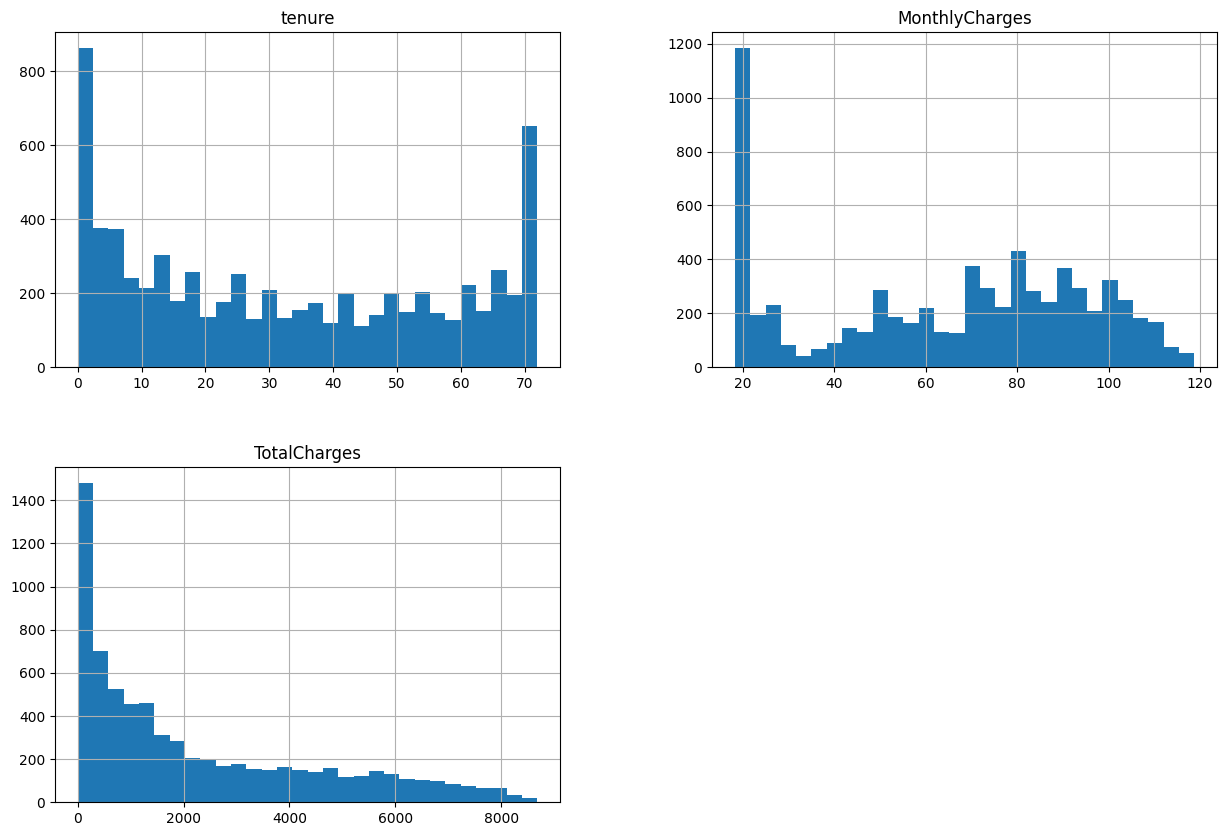

In [ ]:
df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.show()

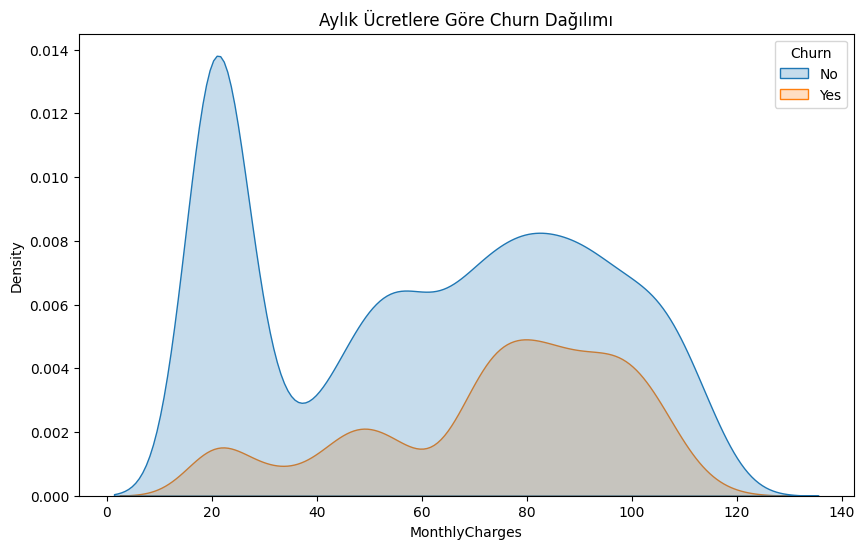

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
plt.title('Aylık Ücretlere Göre Churn Dağılımı')
plt.show()

* Yukarıdaki histogramlar EDA içinde çizilecek. 
* Modele geçmeden önce encoding yapılacak.
* Küçük Bir Hatırlatma:
* Encoding işlemini yaptıktan sonra veriyi Scale (Ölçeklendirme) yapıp yapmayacağına karar vermen gerekecek. Çünkü TotalCharges (8000'li rakamlar) ile tenure (0-72 arası) arasında büyük bir ölçek farkı var. Bazı modeller (örneğin Logistic Regression veya KNN) bu farktan dolayı TotalCharges sütununa torpil geçebilir.

* İLK AŞAMA
1. Temizlik: Boşlukları sil, veri tiplerini düzelt, duplicate'leri uçur.

2. Outlier Kontrolü: Sınırların temiz olduğunu gör.

3. Hızlı EDA: Histogramlar, bar chartlar ve Churn ile ilişkiler. Veriyi "tanıma" evresi.

4. Feature Engineering / Encoding: Veriyi modele hazırlama (Sayıya çevirme).

5. Scaling & Modeling: Son dokunuş ve makine öğrenmesi.

ENCODING AŞAMASI İÇİN GEREKLİ KODLAR AŞAĞIDA

In [ ]:
"""
#1. Binary Encoding (0 ve 1)
# Cinsiyet ve Yes/No sütunlarını belirleyelim
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    # Male/Yes -> 1, Female/No -> 0 (Alfabetik veya mantıksal tercih sana kalmış)
    if col == 'gender':
        df[col] = df[col].map({'Female': 1, 'Male': 0})
    else:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

#2. Ordinal Encoding (Hiyerarşik Sıralama)
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

#3. One-Hot Encoding (Sütunlara Ayırma)
# drop_first=True yaparak 'dummy variable trap'ten (kukla değişken tuzağı) kaçınırız
df = pd.get_dummies(data=df, columns=['PaymentMethod', 'InternetService'], drop_first=True)
"""

"\n#1. Binary Encoding (0 ve 1)\n# Cinsiyet ve Yes/No sütunlarını belirleyelim\nbinary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', \n               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', \n               'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']\n\nfor col in binary_cols:\n    # Male/Yes -> 1, Female/No -> 0 (Alfabetik veya mantıksal tercih sana kalmış)\n    if col == 'gender':\n        df[col] = df[col].map({'Female': 1, 'Male': 0})\n    else:\n        df[col] = df[col].map({'Yes': 1, 'No': 0})\n\n#2. Ordinal Encoding (Hiyerarşik Sıralama)\ndf['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})\n\n#3. One-Hot Encoding (Sütunlara Ayırma)\n# drop_first=True yaparak 'dummy variable trap'ten (kukla değişken tuzağı) kaçınırız\ndf = pd.get_dummies(data=df, columns=['PaymentMethod', 'InternetService'], drop_first=True)\n"